# 03 · Extensión: clasificación **multiclase** (tipo de fractura)

Extensión opcional del proyecto. El dataset binario principal **no** sirve aquí
(no tiene el tipo de fractura), así que se usa otro dataset multiclase, por
ejemplo **Bone Break Classification** (Kaggle, `pkdarabi`): avulsión, conminuta,
espiral, etc.

> Reutiliza las mismas ideas de la Fase 2 (transfer learning, aumentación), pero
> con salida **softmax** de N clases y pérdida `sparse_categorical_crossentropy`.
> Recomendado ejecutar en **Colab con GPU**.

In [1]:
import os, pathlib, sys

_in_colab = 'google.colab' in sys.modules or pathlib.Path('/content').exists()

if _in_colab:
    REPO_URL  = "https://github.com/stevenrq/fracturas-rayos-x.git"
    REPO_PATH = "/content/fracturas-rayos-x"
    if not pathlib.Path(REPO_PATH).exists():
        !git clone $REPO_URL $REPO_PATH
    else:
        !git -C $REPO_PATH pull origin main
    os.chdir(REPO_PATH)
else:
    _here = pathlib.Path.cwd()
    _repo = _here if (_here / 'src').exists() else _here.parent
    os.chdir(_repo)

print("Entorno:", 'Colab' if _in_colab else 'Local')
print("cwd:", os.getcwd())

From https://github.com/stevenrq/fracturas-rayos-x
 * branch            main       -> FETCH_HEAD
Already up to date.
Entorno: Colab
cwd: /content/fracturas-rayos-x


## 1 · Obtener y organizar el dataset

La siguiente celda descarga automáticamente el dataset **Bone Break Classification**
(`pkdarabi`) vía `kagglehub` y lo particiona en `data/processed_multiclass/` (70/15/15).

Requiere credenciales Kaggle configuradas: `~/.kaggle/kaggle.json` o variables de entorno
`KAGGLE_USERNAME` / `KAGGLE_KEY`. Ver: https://github.com/Kaggle/kagglehub#authentication

In [2]:
# Adquisición de datos (idempotente: se omite si data/processed_multiclass/ ya existe)
import subprocess, sys
from pathlib import Path

_dst = Path("data/processed_multiclass")
_has_data = _dst.exists() and any(
    p.is_file() for p in _dst.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

if not _has_data:
    print("Ejecutando src/prepare_data_multiclass.py …")
    result = subprocess.run(
        [sys.executable, "src/prepare_data_multiclass.py"],
        capture_output=True, text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr, file=sys.stderr)
        raise RuntimeError(
            "prepare_data_multiclass.py falló. Revisa credenciales Kaggle:\n"
            "https://github.com/Kaggle/kagglehub#authentication"
        )
else:
    print("✓ data/processed_multiclass/ ya existe, omitiendo descarga.")

Ejecutando src/prepare_data_multiclass.py …
Descargando pkdarabi/bone-break-classification-image-dataset vía kagglehub …
Extracting files...
  Descargado en: /root/.cache/kagglehub/datasets/pkdarabi/bone-break-classification-image-dataset/versions/4
  Raíz de clases detectada: /root/.cache/kagglehub/datasets/pkdarabi/bone-break-classification-image-dataset/versions/4/Bone Break Classification/Bone Break Classification
Clases detectadas (10): ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']
Total de imágenes: 1129
Particionando
  -> /content/fracturas-rayos-x/data/processed_multiclass  (70/15/15 estratificado) …
  train: 786 imágenes
  val  : 165 imágenes
  test : 178 imágenes
  TOTAL: 1129
✓ data/processed_multiclass/ listo.



## 2 · Datasets (multiclase, label_mode="int")

In [3]:
import sys, pathlib
sys.path.insert(0, "src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import data as data_bin   # solo para reutilizar get_augmentation()

IMG_SIZE, BATCH, BASE = (224, 224), 32, pathlib.Path("data/processed_multiclass")
def load(split, shuffle):
    return keras.utils.image_dataset_from_directory(
        BASE/split, image_size=IMG_SIZE, batch_size=BATCH,
        label_mode="int", color_mode="rgb", shuffle=shuffle, seed=42)
train_ds, val_ds, test_ds = load("train", True), load("val", False), load("test", False)
CLASSES = train_ds.class_names
N = len(CLASSES); print("Clases:", CLASSES)
AT = tf.data.AUTOTUNE
train_ds, val_ds, test_ds = (d.cache().prefetch(AT) for d in (train_ds, val_ds, test_ds))

Found 786 files belonging to 10 classes.
Found 165 files belonging to 10 classes.
Found 178 files belonging to 10 classes.
Clases: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


## 3 · Modelo (MobileNetV2 + softmax)

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as prep

def build_multiclass(n, dropout=0.3, base_trainable=False):
    inp = keras.Input(IMG_SIZE + (3,))
    x = data_bin.get_augmentation()(inp)
    x = prep(x)
    base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=x)
    base.trainable = base_trainable
    x = keras.layers.GlobalAveragePooling2D()(base.output)
    x = keras.layers.Dropout(dropout)(x)
    out = keras.layers.Dense(n, activation="softmax")(x)
    return keras.Model(inp, out), base

def compile_mc(m, lr):
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

net, base = build_multiclass(N); net = compile_mc(net, 1e-3)

/tmp/ipykernel_9993/978020031.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=x)


## 4 · Entrenamiento en dos etapas

In [5]:
cbs = [keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max",
        patience=5, restore_best_weights=True),
       keras.callbacks.ModelCheckpoint("models/best_multiclass.keras",
        monitor="val_accuracy", mode="max", save_best_only=True)]

net.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=cbs)

base.trainable = True
for l in base.layers[:100]: l.trainable = False
net = compile_mc(net, 1e-5)
net.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=cbs)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 210ms/step - accuracy: 0.1412 - loss: 2.6760 - val_accuracy: 0.1394 - val_loss: 2.3383
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.1934 - loss: 2.4083 - val_accuracy: 0.2000 - val_loss: 2.2066
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.2583 - loss: 2.2363 - val_accuracy: 0.2303 - val_loss: 2.0984
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.2888 - loss: 2.0515 - val_accuracy: 0.2545 - val_loss: 2.0260
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3397 - loss: 1.9176 - val_accuracy: 0.2788 - val_loss: 2.0104
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3206 - loss: 1.9118 - val_accuracy: 0.2909 - val_loss: 1.9975
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.3817 - loss: 1.8282 - val_accuracy: 0.2909 - val_loss: 1.9365
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.3651 - loss: 1.7881 - val_accuracy: 0.2970 -

## 5 · Evaluación por clase

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step
                       precision    recall  f1-score   support

    Avulsion fracture      0.471     0.421     0.444        19
  Comminuted fracture      0.400     0.348     0.372        23
 Fracture Dislocation      0.306     0.625     0.411        24
  Greenstick fracture      0.500     0.421     0.457        19
    Hairline Fracture      0.389     0.389     0.389        18
    Impacted fracture      0.714     0.357     0.476        14
Longitudinal fracture      0.000     0.000     0.000        12
     Oblique fracture      0.333     0.286     0.308        14
Pathological fracture      0.429     0.571     0.490        21
      Spiral Fracture      0.333     0.214     0.261        14

             accuracy                          0.393       178
            macro avg      0.388     0.363     0.361       178
         weighted avg      0.395     0.393     0.379       178



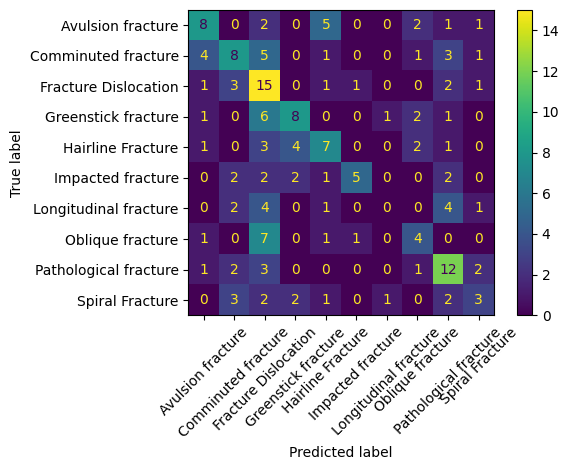

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int)
y_pred = net.predict(test_ds).argmax(1)
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASSES).plot(xticks_rotation=45)
plt.tight_layout(); plt.savefig("reports/figures/cm_multiclase.png", dpi=120, bbox_inches="tight"); plt.show()

## 6 · Notas y limitaciones

- El número y el balance de clases dependen del dataset elegido; añade
  `class_weight` si hay desbalance fuerte.
- Métricas **por clase** (no solo accuracy global): algunas clases raras serán difíciles.
- Es una extensión independiente del clasificador binario desplegado; podrías
  encadenarlos (primero "¿hay fractura?", luego "¿de qué tipo?").